3850-3950 4000-4100

In [ ]:
import os
import pathlib

import warnings
warnings.filterwarnings("ignore")

import FunctionLib as FL
from tqdm import tqdm

import numpy as np
import pandas as pd
import scipy
from scipy.interpolate import interp1d

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['font.family'] = 'serif'

import astropy
import astropy.units as u

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(('./DJAV4.2MiniCatalog.pkl'))
print(DJAv4Catalog.sample_num())
DJAv4Catalog.to_dataframe()


In [6]:
no_coverage_num=0

for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator(1000):
    if not catalog['sample_flag']:
        continue

    coverage_flag=False
    prism_spectrum=FL.Load_Spectrum_From_Fits(catalog['prism_filepath'], catalog['determined_redshift'])
    prism_spectrum.set_boundarys(3800*u.AA, 4150*u.AA)

    for key, grating_filepath in catalog['grating_filepaths'].items():

        grating_spectrum=FL.Load_Spectrum_From_Fits(grating_filepath, catalog['determined_redshift'])

        dual_boundarys=grating_spectrum.dual_boundarys()

        if dual_boundarys[0]>3850*u.AA:
            continue
        # grating_spectrum.set_boundarys(3800*u.AA, 4150*u.AA)

        with astropy.io.fits.open(grating_filepath) as hdul:
            un=hdul[1].data['ERR']
            sig=hdul[1].data['flux']


        # fig, ax = plt.subplots(figsize=(25,14))
        # ax.plot(prism_spectrum.processing_wavelengths, prism_spectrum.processing_flux_lambda, label='Prism', color='C0')
        # ax.plot(grating_spectrum.processing_wavelengths, grating_spectrum.processing_flux_lambda, label='Grating', color='C1')
        # ax.set_xlabel('Wavelength (AA)', fontsize=24)
        # ax.set_ylabel(r'Flux Density ($10^{-17} erg/s/cm^2/\AA$)', fontsize=24)
        # ax.set_ylim(-1e-18,2e-18)
        # ax.tick_params(axis='both', which='major', labelsize=20)
        # ax.legend(fontsize=20)
        # plt.show()

    break


(0.0, 5.0)

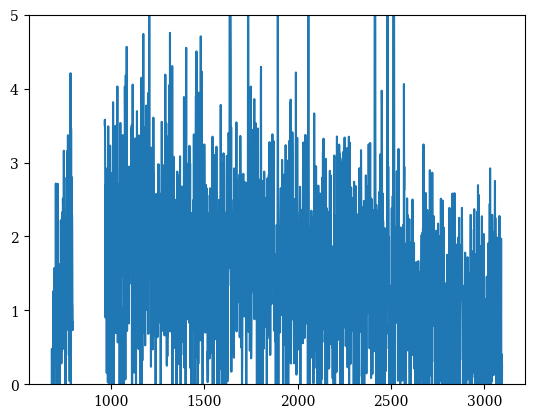

In [12]:
plt.plot((sig/un))
plt.ylim(0,5)